IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [175]:
# Descarga de datos desde Kaggle

#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("mshepherd/board-games")

#print("Path to dataset files:", path)

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [178]:
### ruta de archivos de lectura

data_game_item = pd.read_csv("datos/bgg_GameItem.csv", delimiter=",")#archivo principal

data_category = pd.read_csv("datos/bgg_Category.csv", delimiter=",")
data_game_family = pd.read_csv("datos/bgg_GameFamily.csv", delimiter=",")
data_game_type = pd.read_csv("datos/bgg_GameType.csv", delimiter=",")
data_mechanic = pd.read_csv("datos/bgg_Mechanic.csv", delimiter=",")
data_person = pd.read_csv("datos/bgg_Person.csv", delimiter=",")
data_publisher = pd.read_csv("datos/bgg_Publisher.csv", delimiter=",")



data_game_item.columns
#CHAT GPT me ayudo, promto:     https://chatgpt.com/share/68ac865e-6c6c-8002-bdaa-1ea853e1d4b3
tmp = data_game_item.copy()


data_category = dict(zip(data_category.bgg_id.astype(str), data_category.name.astype(str)))
data_game_family = dict(zip(data_game_family.bgg_id.astype(str), data_game_family.name.astype(str)))
data_game_type = dict(zip(data_game_type.bgg_id.astype(str), data_game_type.name.astype(str)))
data_mechanic = dict(zip(data_mechanic.bgg_id.astype(str), data_mechanic.name.astype(str)))
data_person = dict(zip(data_person.bgg_id.astype(str), data_person.name.astype(str)))
data_publisher = dict(zip(data_publisher.bgg_id.astype(str), data_publisher.name.astype(str)))

def ids_a_nombres(celda, mapa):
    if pd.isna(celda) or celda == "": 
        return ""
    ids = str(celda).split(",")
    nombres = []
    seen = set()
    for i in ids:
        k = i.strip()
        if k in mapa and mapa[k] not in seen:
            nombres.append(mapa[k]); seen.add(mapa[k])
    return "|".join(nombres)



tmp["game_type_name"] = tmp["game_type"].astype(str).map(data_game_type).fillna("Nana")#lo limpiamos
##juntamos base de datos respecto a los numeros, en esto me ayudo gpt junto con la funcion, link de lo que me dijo y luego cambie las variables : ), es el mismo que 
### el de antes: https://chatgpt.com/share/68ac865e-6c6c-8002-bdaa-1ea853e1d4b3
tmp["categories"] = tmp["category"].apply(lambda x: ids_a_nombres(x, data_category))
tmp["mechanics"]  = tmp["mechanic"].apply(lambda x: ids_a_nombres(x, data_mechanic))
tmp["families"]   = tmp["family"].apply(lambda x: ids_a_nombres(x, data_game_family))
tmp["publishers"] = tmp["publisher"].apply(lambda x: ids_a_nombres(x, data_publisher))
tmp["designers"]  = tmp["designer"].apply(lambda x: ids_a_nombres(x, data_person))
tmp["artists"]    = tmp["artist"].apply(lambda x: ids_a_nombres(x, data_person))

columnas_escogidas = ["bgg_id","name","min_players", "max_players","min_time", "max_time","min_age","game_type_name","categories","mechanics",
        "families", "year","publishers","artists","designers"]## filtrado de columnas

datos_de_juegos = tmp[columnas_escogidas]




## aqui guardamos la base de datos|
proc_dir = Path("Analisis")#codigo clase 5
proc_dir.mkdir(exist_ok=True)# codigo clase 5
datos_de_juegos.to_csv("Analisis/datos_de_juegos.csv", index=False)

 
dt =datos_de_juegos.copy()#para no tener que escribri mucho:  dt = datos


In [179]:
dt.head(6)#reviso que este todo bien


,bgg_id,name,min_players,max_players,min_time,max_time,min_age,game_type_name,categories,mechanics,families,year,publishers,artists,designers
0,1,Die Macher,3.0,5.0,240.0,240.0,14.0,Strategy Game,Economic|Negotiation|Political,Alliances|Area Majority / Influence|Auction/Bi...,Country: Germany|Political: Elections|Series: ...,1986.0,Hans im Glück|Moskito Spiele|Ediciones MasQueO...,Marcus Gschwendtner|Harald Lieske,Karl-Heinz Schmiel
1,2,Dragonmaster,3.0,4.0,30.0,30.0,12.0,Strategy Game,Card Game|Fantasy,Trick-taking,Components: Gems/Crystals|Creatures: Dragons|T...,1981.0,E.S. Lowe|Milton Bradley,Bob Pepper,"G. W. ""Jerry"" D'Arcey"
2,3,Samurai,2.0,4.0,30.0,60.0,10.0,Strategy Game,Abstract Strategy|Medieval,Area Majority / Influence|Hand Management|Hexa...,Components: Map (Continental / National scale)...,1998.0,Fantasy Flight Games|Hans im Glück|999 Games|A...,Franz Vohwinkel,Reiner Knizia
3,4,Tal der Könige,2.0,4.0,60.0,60.0,12.0,Strategy Game,Ancient,Action Points|Area Majority / Influence|Auctio...,Containers: Triangular Boxes|Country: Egypt|Pr...,1992.0,KOSMOS,Thomas di Paolo,Christian Beierer
4,5,Acquire,2.0,6.0,90.0,90.0,12.0,Strategy Game,Economic|Territory Building,Hand Management|Investment|Market|Square Grid|...,Components: 9 x 12 Grids|Series: 3M Bookshelf ...,1964.0,3M|The Avalon Hill Game Co|Avalon Hill|Dujardi...,Scott Okumura|Peter Whitley,Sid Sackson
5,6,Mare Mediterraneum,2.0,6.0,240.0,240.0,12.0,Nana,Civilization|Nautical,Dice Rolling,Containers: Tubes|Region: Mediterranean Sea,1989.0,Historien Spiele Galerie (Historien Spielegale...,Jean du Poël,Jean du Poël


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



Segun el explorador de archivos, ocupa 23,2 MB, la nueva carpeta y la anterior 17,1 MB. Esto puede ser porque los textos son mas largos que los mismos ID, por ejemplo envez de tener el nombre completo de la persona antes era solo digitos como 1001, que son 4 caracteres y ahroa esta el nombre completo que son varios, por la cantidad de casillas que se repiten, se esta guardando el datos multiples veces, ocupando mas espacio. La diferencia es notoria, porque a su vez tambien achique la base de datos con menos columnas pero pesa 5MB mas, que puede parecer poco al inicio, pero en una BigData las cosas cambian.
Por eso es mejor guardarlos por separados como diccionarios, como y luego utilizo la funcion lambda, para crear como un diccionario recorro la data, para completarla. Como se hizo anteriormente.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

In [180]:
#A y B)
#dt.columns
#dt.year
#sorted(dt["year"])

dt = dt[dt["year"].between(1980,2025)]  ## aqui se filtra con between(año min, año max), los Not a Number(Nan) tambien se van

#sorted(dt["year"])   # con este revise que este bien el año minimo
#sorted(dt["year"],reverse = True)   # aqui revise que este bien el año superior
dt.head(2)


,bgg_id,name,min_players,max_players,min_time,max_time,min_age,game_type_name,categories,mechanics,families,year,publishers,artists,designers
0,1,Die Macher,3.0,5.0,240.0,240.0,14.0,Strategy Game,Economic|Negotiation|Political,Alliances|Area Majority / Influence|Auction/Bi...,Country: Germany|Political: Elections|Series: ...,1986.0,Hans im Glück|Moskito Spiele|Ediciones MasQueO...,Marcus Gschwendtner|Harald Lieske,Karl-Heinz Schmiel
1,2,Dragonmaster,3.0,4.0,30.0,30.0,12.0,Strategy Game,Card Game|Fantasy,Trick-taking,Components: Gems/Crystals|Creatures: Dragons|T...,1981.0,E.S. Lowe|Milton Bradley,Bob Pepper,"G. W. ""Jerry"" D'Arcey"


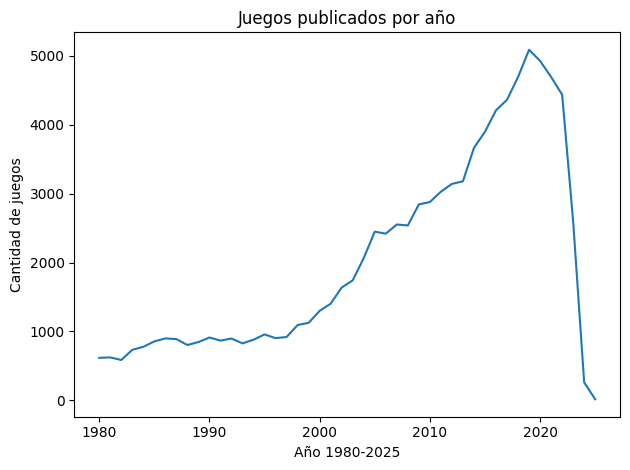

Año:2019con 5087 juegos publicados


In [181]:
#una leve ayuda:      https://chatgpt.com/share/68ae2ed3-1ad8-8002-a07b-db6e2fac0e5a

dg = dt.copy()

dg["year"] = pd.to_numeric(dg["year"])
conteo = dt["year"].dropna().astype(int).value_counts().sort_index()


plt.figure()
conteo.plot()
plt.xlabel("Año 1980-2025")
plt.ylabel("Cantidad de juegos")
plt.title("Juegos publicados por año")
plt.tight_layout()
plt.show()

print(f"Año:{conteo.idxmax()}con {conteo.max()} juegos publicados")#para ver el punto mas alto


Podemos ver claramente una tendecia altista desde los años 2000 luego en la cuarentena se puede ver un descenso drastico de juegos publicados por años. Puede ser por la cuarentena o por falta de registros luegos de esos años, que es lo mas probable, un bajo de registro de juegos apartir del 2020.

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

Como podemos ver en el grafico, el año mas alto es el **2019**, con **3959** juegos publicados

### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

In [182]:
#dt.columns
#sorted(dt["min_time"])
#sorted(dt["max_time"], reverse = True)

dt = dt[dt["min_time"].between(5,60)]
dt = dt[dt["max_time"].between(15,180)]
dt.head(2)#todo bien

,bgg_id,name,min_players,max_players,min_time,max_time,min_age,game_type_name,categories,mechanics,families,year,publishers,artists,designers
1,2,Dragonmaster,3.0,4.0,30.0,30.0,12.0,Strategy Game,Card Game|Fantasy,Trick-taking,Components: Gems/Crystals|Creatures: Dragons|T...,1981.0,E.S. Lowe|Milton Bradley,Bob Pepper,"G. W. ""Jerry"" D'Arcey"
2,3,Samurai,2.0,4.0,30.0,60.0,10.0,Strategy Game,Abstract Strategy|Medieval,Area Majority / Influence|Hand Management|Hexa...,Components: Map (Continental / National scale)...,1998.0,Fantasy Flight Games|Hans im Glück|999 Games|A...,Franz Vohwinkel,Reiner Knizia


a

Al principio, quise filtrar los juegos por duración según su tipo (por ejemplo, los de cartas, dados, o de azar). Usé un código que me ayudó a crear una IA, pero lo descarté porque usaba funciones que no conocía. En su lugar, opté por una solución más simple y realista: ajustar la duración de los juegos a un rango típico para partidas familiares, de 5 a 180 minutos. Aunque exclui los juegos demasiado largos como el D&D lamentablemente. 

Se dejo entre 5 min y 18 0min, que es mas tipico de juegos familiares o de gente normal. 


**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

El problema está entre el teclado y la silla(falta aprender pandas). Debido a que la base de datos está bien estructurada, es ligera y la mayoría de sus datos son verídicos. Aunque existen algunas inconsistencias, como errores puntuales o valores atípicos (por ejemplo, en el tipo de juego, la duración o las casillas con valores "NaN"), se trata de problemas comunes que se resuelven con una limpieza de datos básica. Afortunadamente, no se encontraron problemas más graves, como fechas en formatos distintos, datos mezclados entre columnas (una fecha en una celda de ID, por ejemplo) o una mala migración de información a partir de un año determinado. En este caso, solo fue necesario realizar un filtrado básico para corregir las inconsistencias, como el año de publicación o la duración del juego en relación con su tipo. Por ejemplo, un juego de apuestas(cartas, dados) puede durar un minuto, mientras que uno de estrategia no.